# Electricity Markets

### (I) European Gas Transmission Network

Network Analysis on data about the European natural gas transmission network as provided by the SciGRID_gas project:

Source: https://www.gas.scigrid.de/posts/2020-Sep-02_iggielgn.html

##### Import relevant packages

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs

import networkx as nx 
import pyomo.environ as pe
import pypsa

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

####  Read edges and nodes as GeoDataFrame

In [2]:
# GeoDataFrame for nodes
url_nodes = "https://tubcloud.tu-berlin.de/s/8SMwwWQyn6GiPez/download/scigrid-gas-nodes.geojson"
gdf_nodes = gpd.read_file(url_nodes).set_index("id")

# GeoDataFrame for edges
url_edges = "https://tubcloud.tu-berlin.de/s/fF6KKpWtJyS3BmD/download/scigrid-gas-pipelines.geojson"
gdf_edges = gpd.read_file(url_edges)

In [3]:
# Display Nodes GeoDataFrame
gdf_nodes.head()

,country_code,x,y,geometry
id,,,,
INET_N_855,PL,23.896413,53.017810,POINT (23.89641 53.01781)
INET_N_1828,PL,22.241386,52.984994,POINT (22.24139 52.98499)
INET_N_329,PL,20.619795,52.881484,POINT (20.61979 52.88148)
INET_N_1612,IT,13.592806,46.505528,POINT (13.59281 46.50553)
INET_N_1009,IT,13.416054,46.503733,POINT (13.41605 46.50373)


In [4]:
# Display Edges GeoDataFrame
gdf_edges.head()

,index,diameter_mm,is_bothDirection,length_km,max_cap_M_m3_per_d,max_pressure_bar,start_year,bus0,bus1,geometry
0,INET_PL_273_EE_0_Seg_0_Seg_0,1420.0,0,110.841205,90.410959,84.0,1999.0,INET_N_855,INET_N_1828,"LINESTRING (23.89641 53.01781, 22.24139 52.98499)"
1,INET_PL_273_EE_1_Seg_0_Seg_0,1420.0,0,109.322286,90.410959,84.0,1999.0,INET_N_1828,INET_N_329,"LINESTRING (22.24139 52.98499, 20.61979 52.88148)"
2,INET_PL_357_Seg_0_Seg_0,1219.0,1,13.533434,101.066573,70.0,NaN,INET_N_1612,INET_N_1009,"LINESTRING (13.59281 46.50553, 13.41605 46.50373)"
3,INET_PL_359_Seg_0_Seg_0,1066.8,1,13.533434,101.066573,70.0,NaN,INET_N_1612,INET_N_1009,"LINESTRING (13.59281 46.50553, 13.41605 46.50373)"
4,INET_PL_361_Seg_0_Seg_0,1219.0,1,13.533434,101.066573,70.0,NaN,INET_N_1612,INET_N_1009,"LINESTRING (13.59281 46.50553, 13.41605 46.50373)"


####  Plot of transmission network data on a map

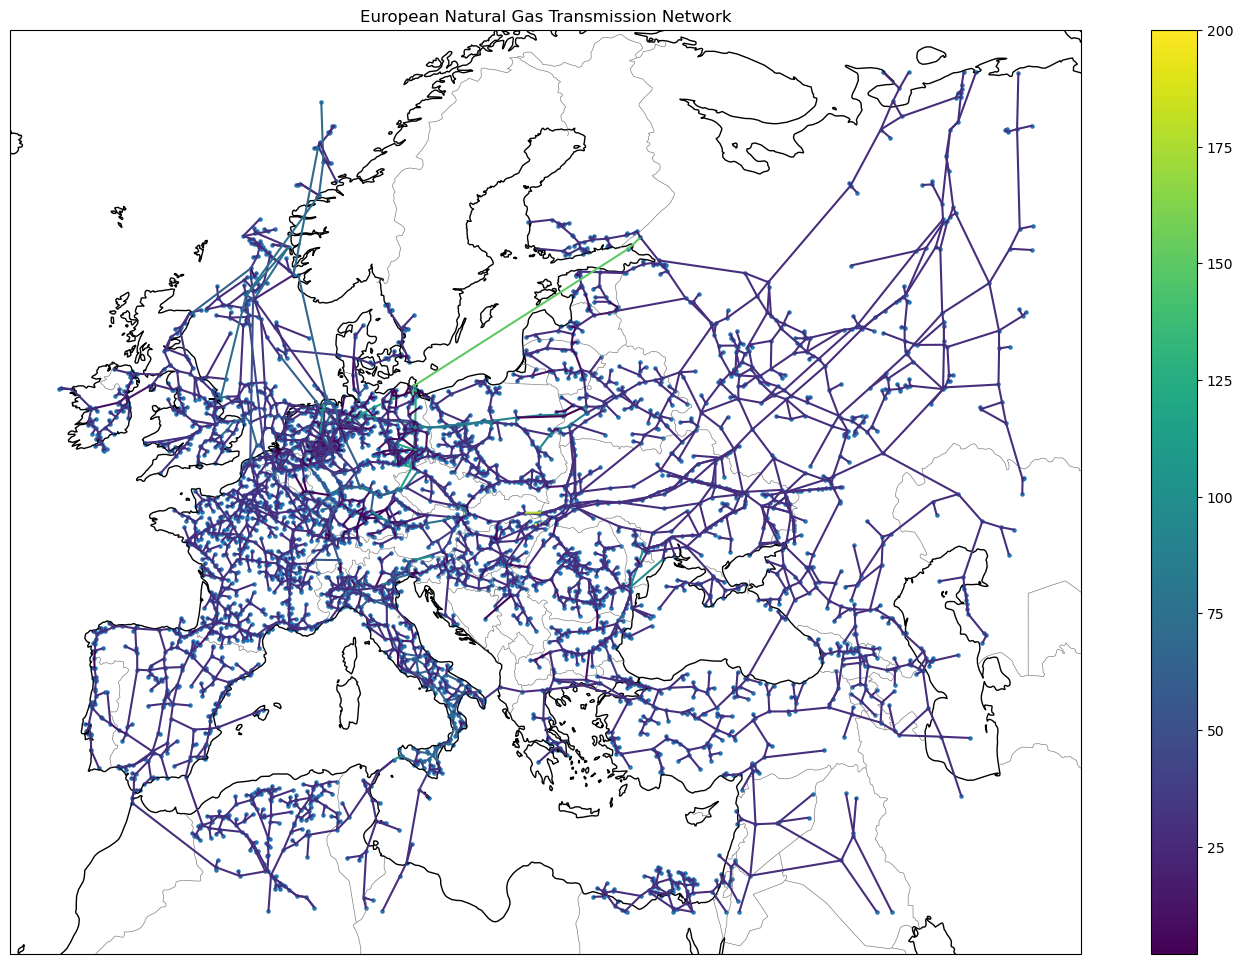

In [5]:
# Define figure and axes for plotting
fig = plt.figure(figsize=(18, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot edges of pipeline on the axes
gdf_edges.plot(
    ax=ax,
    column="max_cap_M_m3_per_d",
    markersize=gdf_edges['max_pressure_bar']*10,
    legend=True,
)

# Plot nodes of pipeline on same axes
gdf_nodes.plot(
    ax=ax,
    markersize=5
)

# Add features of plots
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)
ax.set_title("European Natural Gas Transmission Network")

plt.show()

####  Pipeline(s) with the maximum pressure

In [6]:
highest_pressure_pipelines = gdf_edges.loc[gdf_edges["max_pressure_bar"] == gdf_edges["max_pressure_bar"].max()]
highest_pressure_pipelines.set_index("index", inplace = True)

# Display Results
highest_pressure_pipelines

,diameter_mm,is_bothDirection,length_km,max_cap_M_m3_per_d,max_pressure_bar,start_year,bus0,bus1,geometry
index,,,,,,,,,
PLL_84_Seg_0_Seg_0_Seg_0,1153.0,0,1209.172213,150.68,220.0,2011.0,N_50_L_LMGN,SEQ_2254_p,"LINESTRING (13.42279 54.26859, 28.30912 60.44315)"
PLL_84_Seg_0_Seg_62_Seg_2,1153.0,0,75.621250,150.68,220.0,2011.0,SEQ_2254_p,N_12_L_LMGN,"LINESTRING (28.30912 60.44315, 29.16691 60.96367)"


In [7]:
print(f"The GeoDataFrame clearly shows these pipelines with the maximum pressure of {gdf_edges['max_pressure_bar'].max()} bar are: {', '.join(str(item) for item in highest_pressure_pipelines.index.to_list())}.")

The GeoDataFrame clearly shows these pipelines with the maximum pressure of 220.0 bar are: PLL_84_Seg_0_Seg_0_Seg_0, PLL_84_Seg_0_Seg_62_Seg_2.


####  Subset of pipelines which cross borders

In [8]:
# Initialize the new columns in gdf_edges
gdf_edges['bus0_country_code'] = None
gdf_edges['bus1_country_code'] = None

# Iterate over the rows in gdf_edges and set the country codes
for idx in gdf_edges.index:
    bus0 = gdf_edges.at[idx, 'bus0']
    bus1 = gdf_edges.at[idx, 'bus1']
    gdf_edges.at[idx, 'bus0_country_code'] = gdf_nodes.loc[bus0, 'country_code']
    gdf_edges.at[idx, 'bus1_country_code'] = gdf_nodes.loc[bus1, 'country_code']

# Add the 'cross-borders' column based on the comparison
gdf_edges['cross_borders'] = np.where(
                                      gdf_edges['bus1_country_code'] == gdf_edges['bus0_country_code'], 'No', 'Yes'
                                     )

# Subset of pipelines which cross borders
gdf_cross_border_lines = gdf_edges[gdf_edges['cross_borders'] == 'Yes']


# Subset of nodes which cross borders

# Retrirve set of unique buses that cross borders 
nodes_in_cross_border_lines_data  = set(gdf_cross_border_lines.bus0.tolist() + gdf_cross_border_lines.bus1.tolist())

# Use set to filter gdf_node GeoDataFrame
gdf_cross_border_nodes = gdf_nodes[gdf_nodes.index.isin(nodes_in_cross_border_lines_data)]

In [9]:
print(f"There are {len(gdf_cross_border_lines)} pipelines that cross country borders.\n")

# Display top five longest pipenes
gdf_cross_border_lines.sort_values("length_km", ascending=False)[:5].set_index("index")[["length_km", "diameter_mm", "max_cap_M_m3_per_d", "bus0_country_code", "bus1_country_code"]]

There are 320 pipelines that cross country borders.



,length_km,diameter_mm,max_cap_M_m3_per_d,bus0_country_code,bus1_country_code
index,,,,,
PLL_84_Seg_0_Seg_0_Seg_0,1209.172213,1153.0,150.680000,DE,FI
NO_PS_26_Seg_0_Seg_1,830.425819,1067.0,50.146193,XX,FR
NO_PS_10_Seg_0_Seg_0,810.140145,1016.0,42.932180,XX,BE
NO_PS_0_Seg_0_Seg_0_Seg_0,704.818321,1067.0,70.000000,XX,NO
PLL_470_Seg_0_Seg_0,693.654532,900.0,27.809143,XX,ES


##### Percentage of lines that cross borders

In [11]:
print(f" The percentage of lines that cross borders is {((len(gdf_cross_border_lines)/len(gdf_edges)*100)):.2f}%.")

 The percentage of lines that cross borders is 5.17%.


####  Networkx.Graph from the pipeline data

In [12]:
# Build network including pipeline capacity and rated pipeline pressure as edge attributes
N = nx.from_pandas_edgelist(gdf_edges, "bus0", "bus1", edge_attr=["length_km","diameter_mm", "max_cap_M_m3_per_d", "max_pressure_bar"])

# Compute the degrees of nodes
degrees = [val for node, val in N.degree()]

print(f"The Network {N}.\nThe average degree of the network is {np.mean(degrees):.2f}.")

The Network Graph with 4659 nodes and 5566 edges.
The average degree of the network is 2.39.


####  Frequency distribution of degrees as histogram.

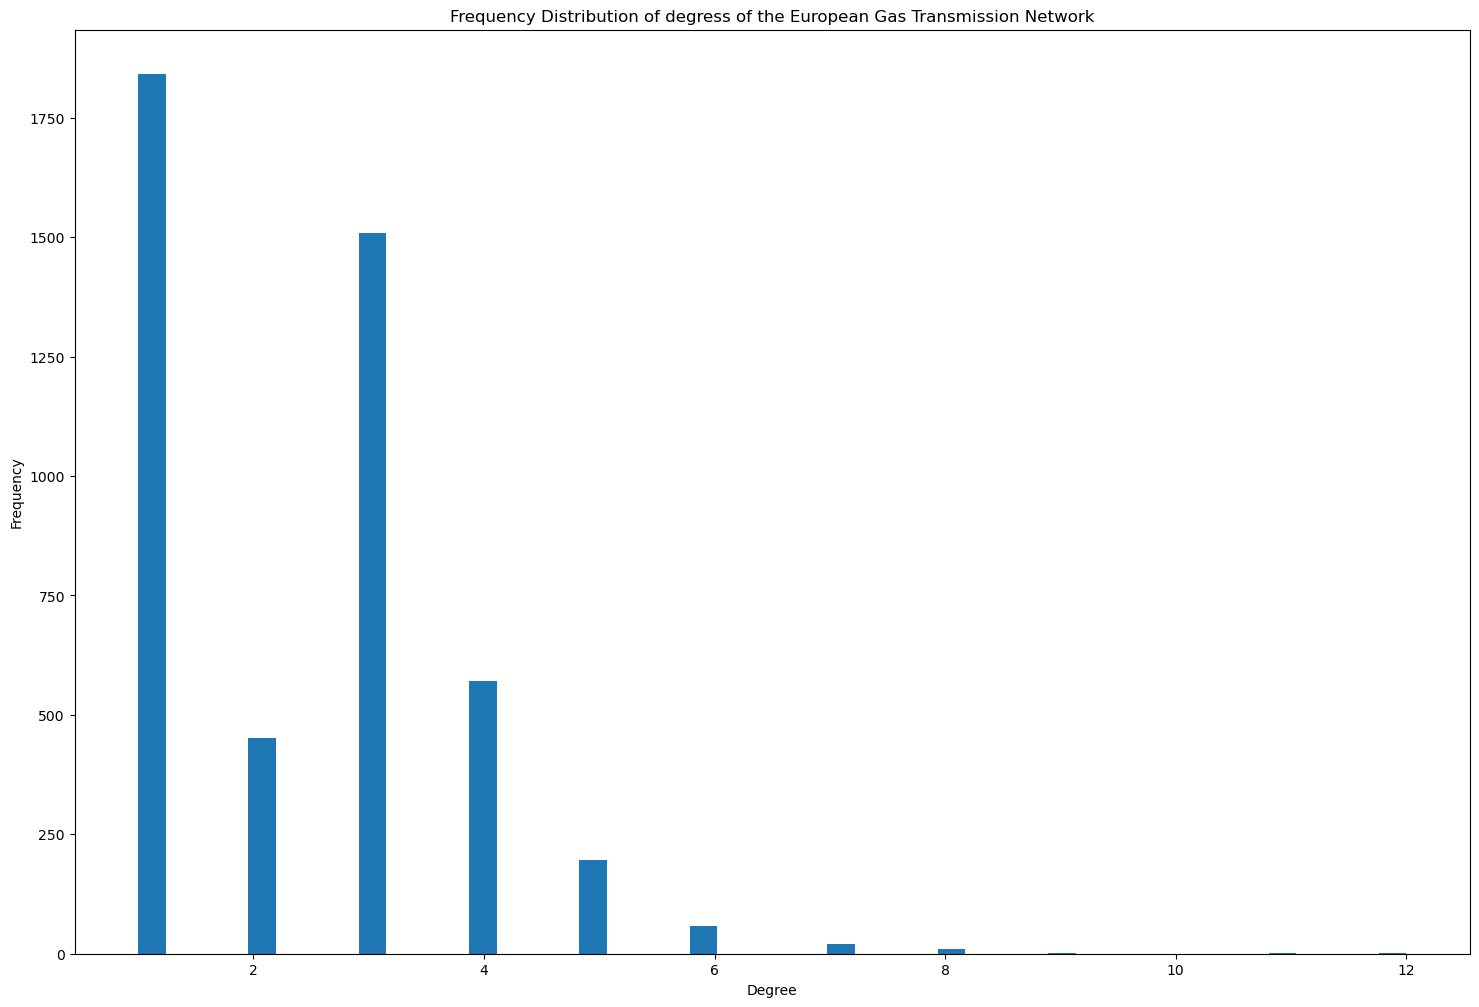

In [13]:
fig = plt.figure(figsize=(18, 12))

plt.hist(degrees, bins="auto")
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of degress of the European Gas Transmission Network')

plt.show()

####  Compute and plot the incidence matrix of the network

In [14]:
K = nx.incidence_matrix(N, oriented=True).todense()
K

array([[-1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 1., -1.,  0., ...,  0.,  0.,  0.],
       [ 0.,  1., -1., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0., -1.],
       [ 0.,  0.,  0., ...,  0.,  0.,  1.]])

### (II) Merit Order

Build and plot merit order curves for the German day-ahead electricity market given a dataset on operational power plants and additional carrier-specific data:

The attributes contained in the files have the following units:

|Attribute |Description |Unit |
|---------|--------|----------|
carrier | technology | – |
co2_emissions | specific carbon dioxide emissions | t/MWh (thermal) |
color | HEX | - |
efficiency | conversion efficiency | MWh (electric) / MWh (thermal) |
marginal_cost | STMGC | €/MWh (electric) |
p_max_pu | capacity factor in particular hour | p.u. |
p_nom | rated/nominal capacity | MW |

Assumption: All storage have sufficient energy filling levels to dispatch at full capacity.

####  Read the provided datasets into two separate pandas.DataFrame.

In [16]:
# Read powerplants DataFrame
url_powerplants = "https://tubcloud.tu-berlin.de/s/P9qPttqFg3ciKEy/download/powerplants.csv"
df_powerplants = pd.read_csv(url_powerplants, index_col = 0)

# Read technologies DataFrame
url_technologies = "https://tubcloud.tu-berlin.de/s/XjtnxyNPtPP6eDQ/download/technologies.csv"
df_technologies = pd.read_csv(url_technologies) 

##### Format Power plant DataFrame

In [17]:
# Display powerplant DataFrame
df_powerplants.head()

,efficiency,marginal_cost,p_nom,carrier,p_max_pu
3371 biomass,0.470000,14.893617,20.569100,biomass,1.000000
3371 onwind,1.000000,2.000000,206.573309,onshore wind,0.085297
3371 ror,0.900000,3.000000,44.060000,run of river,0.660853
3371 solar,1.000000,1.000000,324.967191,solar,0.159534
3372 CCGT,0.586794,38.453915,1822.000000,CCGT,1.000000


In [18]:
# Rename columns to include units
df_powerplants.rename(columns = {"efficiency":"efficiency [MWhel/MWhth]", "marginal_cost":"marginal_cost [€/MWhel]", "p_nom":"p_nom [MW]", "p_max_pu":"p_max_pu [p.u.]"}, inplace = True)

df_powerplants.head()

,efficiency [MWhel/MWhth],marginal_cost [€/MWhel],p_nom [MW],carrier,p_max_pu [p.u.]
3371 biomass,0.470000,14.893617,20.569100,biomass,1.000000
3371 onwind,1.000000,2.000000,206.573309,onshore wind,0.085297
3371 ror,0.900000,3.000000,44.060000,run of river,0.660853
3371 solar,1.000000,1.000000,324.967191,solar,0.159534
3372 CCGT,0.586794,38.453915,1822.000000,CCGT,1.000000


##### Format Technologies DataFrame

In [19]:
# Display powerplant DataFrame
df_technologies.head()

,Carrier,co2_emissions,color
0,onshore wind,0.0,#235ebc
1,solar,0.0,#f9d002
2,nuclear,0.0,#ff9000
3,biomass,0.0,#0c6013
4,CCGT,0.2,#b20101


In [20]:
# Rename columns to include units
df_technologies.rename(columns = {"Carrier":"carrier", "co2_emissions":"co2_emissions [t/MWhth]"}, inplace = True)

# Set carrier as index column
df_technologies.set_index('carrier', inplace = True)

df_technologies.head()

,co2_emissions [t/MWhth],color
carrier,,
onshore wind,0.0,#235ebc
solar,0.0,#f9d002
nuclear,0.0,#ff9000
biomass,0.0,#0c6013
CCGT,0.2,#b20101


####  Merit order Python Function

In [21]:
import matplotlib.patches as mpatches

def merit_order_curve(df, df_carrier, title = None, demand  = None, CO2_price = None, plot = True):
    # Merit order curve arguments
    # (1) df - power plant data
    # (2) df_carrrier - carrier specific information
    # (3) title* - Plot title
    # (4) demand* - Electricity demand
    # (5) CO2_price* - CO2_price €/tCO2
    # (6) plot* - Plot if True, returns dataframe if False
    # *Optional arguments

    # Compute available capacity
    df["available_capacity [MW]"] = df["p_nom [MW]"]*df["p_max_pu [p.u.]"]

    # Merge DataFrames to include co2_emissions values and color columns
    df = df.merge(df_carrier, on='carrier')

    # For additional CO2 price
    if CO2_price:
       df["marginal_cost [€/MWhel]"] = df["marginal_cost [€/MWhel]"] + (CO2_price * df["co2_emissions [t/MWhth]"] / df["efficiency [MWhel/MWhth]"]) 
    else:
        pass
    
    # Sort by ascending marginal_cost
    df.sort_values("marginal_cost [€/MWhel]", inplace = True)
    
    # Compute cumulaitve sum column
    df["cumulative_capacity [MW]"] = df["available_capacity [MW]"].cumsum() 
    
    for idx in df.index:
        
        #get index number based on index name
        i = df.index.get_loc(idx)
        
        if idx == "solar":    #First index
            df.loc[idx, "xpos"] = df.loc[idx, "available_capacity [MW]"]
            
        else:
            #Sum of cumulative capacity in the row above and the half of available capacity in 
            index_cumsum = df.columns.get_loc("cumulative_capacity [MW]")
            df.loc[idx, "xpos"] = df.loc[idx, "available_capacity [MW]"]/2 + df.iloc[i-1, index_cumsum]    
                    
    # To return only plots, else return dataframe
    if plot:
        plt.figure(figsize = (20, 12))
        plt.rcParams["font.size"] = 16
        colors = df["color"]
        xpos = (df["xpos"]/1000).values.tolist() # convert to GW
        y = df["marginal_cost [€/MWhel]"].values.tolist()
        
        #width of each bar
        w = (df["available_capacity [MW]"]/1000).values.tolist() # convert to GW
     
        fig = plt.bar(xpos, 
                      height = y,
                      width = w,
                      fill = True,
                      color = colors
                     )

        # Create a custom legend    
        unique_labels = df[["color", "carrier"]].drop_duplicates()
        legend_patches = [mpatches.Patch(color=row["color"], label=row["carrier"]) for idx, row in unique_labels.iterrows()]
  
        plt.xlim(0, (df["available_capacity [MW]"]/1000).sum())
        plt.ylim(0, df["marginal_cost [€/MWhel]"].max())
        
        plt.xlabel("Power plant capacity (GW)")
        plt.ylabel("Marginal Cost (€/MWh)")
        plt.legend(handles=legend_patches, title="Technology")
        plt.title(f"{title}")
        plt.show()
    else:
        return df

####  Plot the merit order curve

##### CASE ONE - Marginal costs only

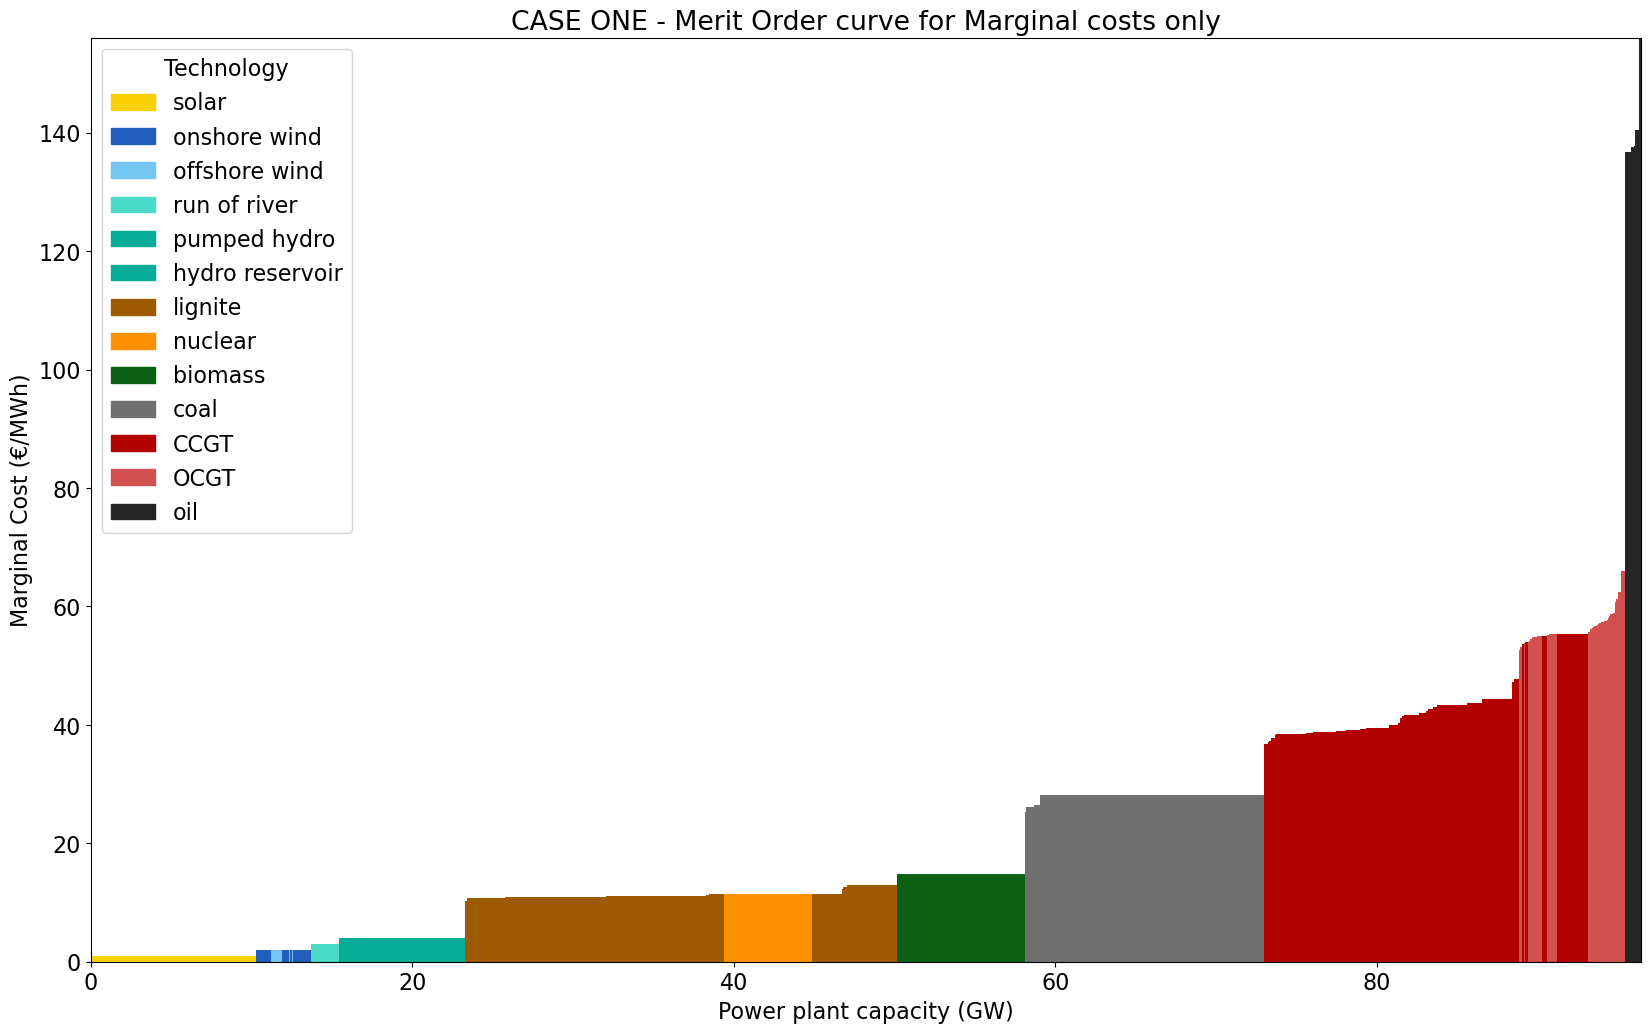

In [22]:
merit_order_curve(df_powerplants,df_technologies, title = "CASE ONE - Merit Order curve for Marginal costs only")

##### (ii) CASE TWO - Merit Order curve for case two - Marginal costs plus 70 €/CO2

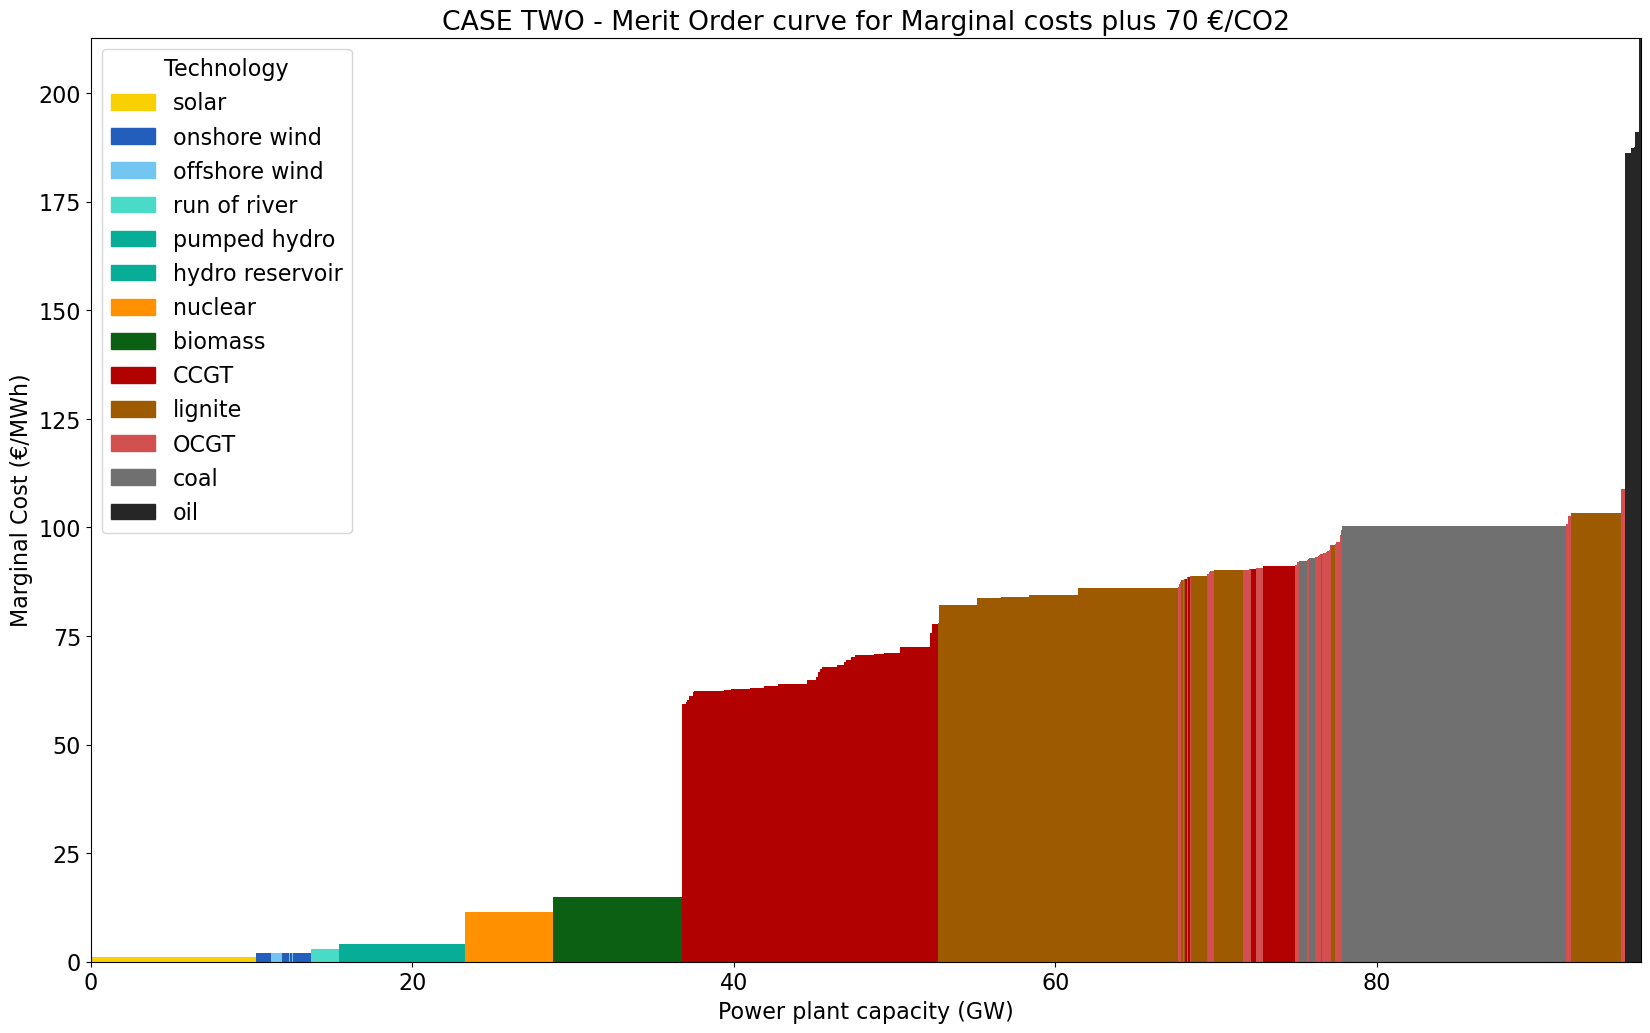

In [23]:
merit_order_curve(df_powerplants,df_technologies,CO2_price=70, title="CASE TWO - Merit Order curve for Marginal costs plus 70 €/CO2")

##### (iii) CASE THREE - Marginal costs plus 70 €/CO2 plus increased gas price of 50 €/MWhth

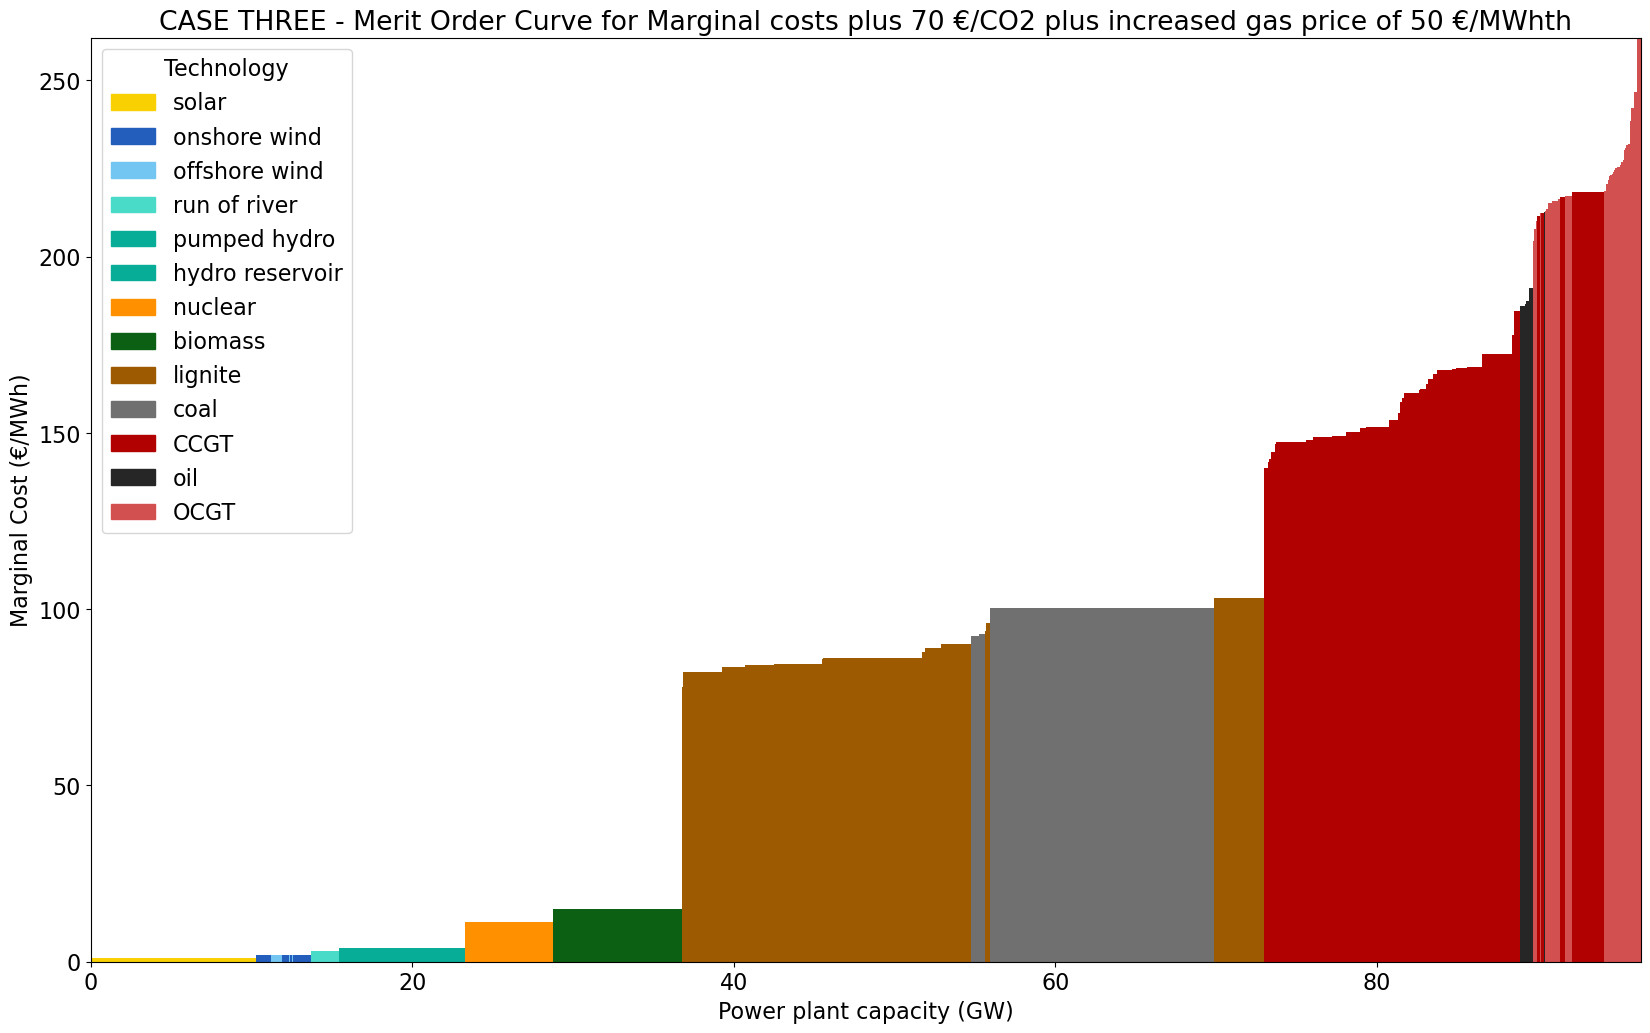

In [24]:
# Create a copy of original dataframe
df_added_gas_price = df_powerplants.copy()

# Create filter
mask = df_added_gas_price['carrier'].isin(['OCGT', 'CCGT'])

# Add increased gas price of 50 €/MWhth to rows with gas powerplants
df_added_gas_price.loc[mask, 'marginal_cost [€/MWhel]'] += 50 / df_added_gas_price.loc[mask, 'efficiency [MWhel/MWhth]']

# Plot merit order curve
merit_order_curve(df_added_gas_price,df_technologies, CO2_price=70,plot=True, title="CASE THREE - Merit Order Curve for Marginal costs plus 70 €/CO2 plus increased gas price of 50 €/MWhth")

####  For each of the cases, use code to present for an electricity demand of 69 GW in a single table

In [25]:
# Return resulting daataframes using the merit_order_curve function for each case

case_i = merit_order_curve(df_powerplants, df_technologies, plot = False)
case_ii = merit_order_curve(df_powerplants, df_technologies, CO2_price=70, plot = False)
case_iii = merit_order_curve(df_added_gas_price, df_technologies, CO2_price=70, plot = False)

In [26]:
cases = [case_i, case_ii, case_iii]

# Intialize the results
results = []
market_clearing_prices = []
market_clearing_price_technologies = []
carbon_intensities = []

# Loop through the cases in 
for each_case in cases:
    case = each_case.copy()
    case = case.reset_index(drop=True)

    # Calculate the minimum capacity to cover the demand of 69 GW
    electricity_demand = 69000 #MW
    sufficient_capacity = case.loc[case['cumulative_capacity [MW]'] > electricity_demand, 'cumulative_capacity [MW]'].iloc[0]
    index = case.index[case['cumulative_capacity [MW]'] == sufficient_capacity].tolist()[0]
    case = case.iloc[:index + 1][["carrier", "marginal_cost [€/MWhel]", "available_capacity [MW]", "efficiency [MWhel/MWhth]", "co2_emissions [t/MWhth]"]]

    # Calculate the market clearing price and its corresponding technology 
    market_clearing_price = case.loc[index]["marginal_cost [€/MWhel]"]
    market_clearing_price_technology = case.loc[index]["carrier"]

    # Calculate the total_power_dispatched
    total_power_dispatched = case.groupby('carrier')['available_capacity [MW]'].sum()

    # Resulting revenue per technology
    case["revenue [€]"] = market_clearing_price * case["available_capacity [MW]"]
    revenue = case.groupby('carrier')["revenue [€]"].sum()

    # Operational costs per technology
    case["operating_costs [€]"] = case["marginal_cost [€/MWhel]"] * case["available_capacity [MW]"]
    operating_costs = case.groupby('carrier')["operating_costs [€]"].sum()

    # Profits per technology
    case["profit [€]"] = case["revenue [€]"] - case["operating_costs [€]"]
    profit = case.groupby('carrier')["profit [€]"].sum()

    # Carbon intensity per technology
    case["carbon_intensity [€]"] = ((case["available_capacity [MW]"] * case['co2_emissions [t/MWhth]'] / case["efficiency [MWhel/MWhth]"]).sum()) / (case['available_capacity [MW]'].sum())
    carbon_intensity = case["carbon_intensity [€]"].sum()
    
    result_dict = {
        "Total Power dispatched [MW]": total_power_dispatched,
        "Revenue [€]": revenue,
        "Operating Costs [€]": operating_costs,
        "Profit [€]": profit
    }
    
    results.append(result_dict)
    market_clearing_prices.append(market_clearing_price)
    market_clearing_price_technologies.append(market_clearing_price_technology)    
    carbon_intensities.append(carbon_intensity)
    

##### CASE ONE - Marginal costs only

In [27]:
print(f"The market clearing price of {market_clearing_prices[0]:.2f} € is set by {market_clearing_price_technologies[0].capitalize()} and the carbon intensity of the system is {carbon_intensities[0]:.2f} tCO2/MWh.\n")
pd.DataFrame(results[0])

The market clearing price of 28.20 € is set by Coal and the carbon intensity of the system is 511.58 tCO2/MWh.



,Total Power dispatched [MW],Revenue [€],Operating Costs [€],Profit [€]
carrier,,,,
biomass,8004.647826,225706.812185,119218.159111,106488.653074
coal,11407.866942,321667.278465,319826.195328,1841.083137
hydro reservoir,169.500000,4779.386364,678.000000,4101.386364
lignite,21375.403267,602721.598180,242876.813699,359844.784481
nuclear,5468.000000,154181.030303,62219.212121,91961.818182
offshore wind,861.509114,24291.946369,1723.018227,22568.928142
onshore wind,2561.602368,72229.424355,5123.204737,67106.219618
pumped hydro,7659.620000,215978.073030,30638.480000,185339.593030
run of river,1777.275355,50113.779314,5331.826064,44781.953251


##### CASE TWO - Marginal costs plus 70 €/CO2

In [28]:
print(f"The market clearing price of {market_clearing_prices[1]:.2f} € is set by {market_clearing_price_technologies[1].capitalize()} and the carbon intensity of the system is {carbon_intensities[1]:.2f} tCO2/MWh.\n")
pd.DataFrame(results[1])

The market clearing price of 88.93 € is set by Lignite and the carbon intensity of the system is 347.54 tCO2/MWh.



,Total Power dispatched [MW],Revenue [€],Operating Costs [€],Profit [€]
carrier,,,,
CCGT,16199.029000,1.440568e+06,1.086492e+06,354076.579795
OCGT,345.321000,3.070916e+04,3.026103e+04,448.129258
biomass,8004.647826,7.118478e+05,1.192182e+05,592629.602148
hydro reservoir,169.500000,1.507352e+04,6.780000e+02,14395.517056
lignite,16108.014362,1.432475e+06,1.366960e+06,65514.653977
nuclear,5468.000000,4.862654e+05,6.221921e+04,424046.223058
offshore wind,861.509114,7.661341e+04,1.723018e+03,74890.387775
onshore wind,2561.602368,2.278015e+05,5.123205e+03,222678.311427
pumped hydro,7659.620000,6.811647e+05,3.063848e+04,650526.196775


##### CASE THREE - Marginal costs plus 70 €/CO2 plus increased gas price of 50 €/MWhth

In [29]:
print(f"The market clearing price of {market_clearing_prices[2]:.2f} € is set by {market_clearing_price_technologies[2].capitalize()} and the carbon intensity of the system is {carbon_intensities[2]:.2f} tCO2/MWh.\n")
pd.DataFrame(results[2])

The market clearing price of 100.32 € is set by Coal and the carbon intensity of the system is 498.85 tCO2/MWh.



,Total Power dispatched [MW],Revenue [€],Operating Costs [€],Profit [€]
carrier,,,,
biomass,8004.647826,8.030117e+05,1.192182e+05,6.837936e+05
coal,14137.533581,1.418252e+06,1.410867e+06,7.384855e+03
hydro reservoir,169.500000,1.700393e+04,6.780000e+02,1.632593e+04
lignite,18265.947603,1.832407e+06,1.563434e+06,2.689729e+05
nuclear,5468.000000,5.485398e+05,6.221921e+04,4.863206e+05
offshore wind,861.509114,8.642503e+04,1.723018e+03,8.470201e+04
onshore wind,2561.602368,2.569753e+05,5.123205e+03,2.518521e+05
pumped hydro,7659.620000,7.683992e+05,3.063848e+04,7.377607e+05
run of river,1777.275355,1.782930e+05,5.331826e+03,1.729612e+05


####  Major differences between the three cases

##### The major differerences in the three cases are their market clearing prices and carbon intensity. See detailed epxlanation below:

#####  From case_i to case_ii we notice the following:
 With additional costs to CO2 emissions; there is a significant increase in market clearing price.<br>

(ii) There is a significant decrease in the carbon intensity of the system since the carbon intensive technologies are pushed out of the market due to higher operating costs from the CO2 price.

            
##### From case_ii to case_iii we notice the following:
(iii) The carbon intensity increases; this observation can be explained by the increased gas price which will push the gas power plants (CCGT and OCGT) further down the merit order curve and out of the market. Therefore, more carbon intense technologies like Lignite and Coal become cheaper than Gas and are now the dispatching technologies.
            
##### (iv) There is a general trend of increased  revenue, operating costs and profit due to the high market clearing price caused by the the added CO2 pirce if of 70 €/tCO2 and added gas prices of 50 €/MWh𝑡ℎ. <br>
Note: In case_iii, the increased gas prices do not necessarily contribute directly to the revenue but they make way for carbon intense technologies and now more expensive power plants to dispatch power.


### (III) Tools for Electricity Market Modelling

Build a simple electricity market model for minimising operational costs within technical constraints
for three fictive countries Aloria, Baray and Corsova considering the following information:

The operational fleet of power plants in the three countries is specified as follows:

|Technology |Country |Marginal Cost [€/MWh] |Capacity [MW]|
|---------|--------|----------|---------|
Coal | Aloria | 34 | 51000 |
Wind and Solar | Aloria | 0 | 9000|
Gas | Aloria | 75 | 12500 |
Hydro | Baray | 5 | 2100 |
Gas | Baray| 70 | 1000 |
Hydro | Corsova | 8 | 1400 |

The electricity demand in the countries reads as follows:
|Country |Demand [MW]|
|---------|--------|
Aloria | 64000 |
Baray| 1200 |
Corsova | 800 |

The transmission capacities read as follows:
|Start | End |Demand [MW]|
|---------|--------|------|
Aloria | Baray | 600 |
Baray| Corsova | 50 |
Aloria | Corsova | 200 |

Assumption: All transmission lines have equal non-zero reactances.

####  Build and solve the problem using pyomo

#####  Create all variables for generation and transmission

In [30]:
#### Initialize model object
m = pe.ConcreteModel()

# To signal that duals are desired, declare a suffix (another pyomo component) with the name “dual” on the model.
m.dual = pe.Suffix(direction=pe.Suffix.IMPORT)

In [31]:
# Electricity market data
# To reduce verbosity note the following substitutions; Aloria - AL, Baray - BY, Corsova - CV
generators = ["Coal", "Wind_Solar", "Gas", "Hydro"]
countries = ["AL", "BY", "CV"]

# Create Dictionary for Capacities
emm_capacities = {
                "AL": {"Coal": 51000, "Wind_Solar": 9000, "Gas": 12500, "Hydro": 0},
                "BY": {"Gas": 1000, "Hydro": 2100},
                "CV": {"Hydro": 1400}
                }

# Create Dictionary for Marginal Costs
emm_marginal_costs = {
                "AL": {"Coal": 34, "Wind_Solar": 0, "Gas": 75, "Hydro": 0},
                "BY": {"Coal": 0, "Wind_Solar": 0, "Gas": 70, "Hydro": 5},
                "CV": {"Coal": 0, "Wind_Solar": 0, "Gas": 0, "Hydro": 8}
                }

# Create Series for Electricity Demand
emm_electricity_demand = pd.Series([64000, 1200, 800], index=countries)
emm_electricity_demand = emm_electricity_demand.to_dict()

# Define transmission capacities
emm_transmission_capacities = {
                            "Start": ["AL", "BY", "AL"],
                            "End": ["BY", "CV", "CV"],
                            "Capacity [MW]": [600, 50, 200]
                                }

In [32]:
# Create generator dispatch variables
m.countries = pe.Set(initialize=emm_electricity_demand.keys())

technologies = (emm_capacities["AL"].keys() | emm_capacities["BY"])
m.technologies = pe.Set(initialize=technologies)

m.g = pe.Var(m.countries, m.technologies, within=pe.NonNegativeReals)

data source (type: set).  This WILL potentially lead to nondeterministic
behavior in Pyomo


In [33]:
# Additional variable for the flows
m.flow_AL_BY = pe.Var()
m.flow_BY_CV = pe.Var()
m.flow_AL_CV = pe.Var()

##### (ii) Formulate the objective function for minimising the operational costs

In [34]:
m.cost = pe.Objective(
                      expr=sum(emm_marginal_costs[c][s] * m.g[c, s] for s in m.technologies for c in m.countries)
                     )
m.cost.pprint()

cost : Size=1, Index=None, Active=True
    Key  : Active : Sense    : Expression
    None :   True : minimize : 75*g[AL,Gas] + 70*g[BY,Gas] + 0*g[CV,Gas] + 34*g[AL,Coal] + 0*g[BY,Coal] + 0*g[CV,Coal] + 0*g[AL,Wind_Solar] + 0*g[BY,Wind_Solar] + 0*g[CV,Wind_Solar] + 0*g[AL,Hydro] + 5*g[BY,Hydro] + 8*g[CV,Hydro]


##### (iii) Build the necessary constraints, including the technical limits of generation and transmission and the Kirchhoff Laws

In [35]:
# Add generator limits
@m.Constraint(m.countries, m.technologies)
def generator_limit(m, c, s):
    return m.g[c, s] <= emm_capacities[c].get(s, 0)

m.generator_limit.pprint()

generator_limit : Size=12, Index=generator_limit_index, Active=True
    Key                  : Lower : Body             : Upper   : Active
          ('AL', 'Coal') :  -Inf :       g[AL,Coal] : 51000.0 :   True
           ('AL', 'Gas') :  -Inf :        g[AL,Gas] : 12500.0 :   True
         ('AL', 'Hydro') :  -Inf :      g[AL,Hydro] :     0.0 :   True
    ('AL', 'Wind_Solar') :  -Inf : g[AL,Wind_Solar] :  9000.0 :   True
          ('BY', 'Coal') :  -Inf :       g[BY,Coal] :     0.0 :   True
           ('BY', 'Gas') :  -Inf :        g[BY,Gas] :  1000.0 :   True
         ('BY', 'Hydro') :  -Inf :      g[BY,Hydro] :  2100.0 :   True
    ('BY', 'Wind_Solar') :  -Inf : g[BY,Wind_Solar] :     0.0 :   True
          ('CV', 'Coal') :  -Inf :       g[CV,Coal] :     0.0 :   True
           ('CV', 'Gas') :  -Inf :        g[CV,Gas] :     0.0 :   True
         ('CV', 'Hydro') :  -Inf :      g[CV,Hydro] :  1400.0 :   True
    ('CV', 'Wind_Solar') :  -Inf : g[CV,Wind_Solar] :     0.0 :   True


In [36]:
# Add Transmission limits

# Initialize Line limit object
m.line_limit = pe.ConstraintList()

transmission = emm_transmission_capacities['Capacity [MW]']

# Add line limit for each line
m.line_limit.add(expr = (-transmission[0], m.flow_AL_BY, transmission[0]))
m.line_limit.add(expr = (-transmission[1], m.flow_BY_CV, transmission[1]))
m.line_limit.add(expr = (-transmission[2], m.flow_AL_CV, transmission[2]))

# Display line limits
m.line_limit.pprint()

line_limit : Size=3, Index=line_limit_index, Active=True
    Key : Lower  : Body       : Upper : Active
      1 : -600.0 : flow_AL_BY : 600.0 :   True
      2 :  -50.0 : flow_BY_CV :  50.0 :   True
      3 : -200.0 : flow_AL_CV : 200.0 :   True


In [37]:
# Add KCL constraints

@m.Constraint(m.countries)
def kcl(m, c):
    if c == "AL":
        sign1 = 1
        sign2 = 0
        sign3 = -1
    elif c == "BY": 
        sign1 = 0
        sign2 = -1
        sign3 = 1 # minimal incidence matrix
    else: #CV
        sign1 = -1
        sign2 = 1
        sign3 = 0

    return sum(m.g[c,s] for s in m.technologies)  + sign1 * m.flow_AL_CV + sign2 * m.flow_BY_CV + sign3 * m.flow_AL_BY == emm_electricity_demand[c] 

# Display constraint
m.kcl.pprint()

kcl : Size=3, Index=countries, Active=True
    Key : Lower   : Body                                                                                             : Upper   : Active
     AL : 64000.0 : g[AL,Gas] + g[AL,Coal] + g[AL,Wind_Solar] + g[AL,Hydro] + flow_AL_CV + 0*flow_BY_CV - flow_AL_BY : 64000.0 :   True
     BY :  1200.0 : g[BY,Gas] + g[BY,Coal] + g[BY,Wind_Solar] + g[BY,Hydro] + 0*flow_AL_CV - flow_BY_CV + flow_AL_BY :  1200.0 :   True
     CV :   800.0 : g[CV,Gas] + g[CV,Coal] + g[CV,Wind_Solar] + g[CV,Hydro] - flow_AL_CV + flow_BY_CV + 0*flow_AL_BY :   800.0 :   True


In [38]:
# Add KVL constraints
m.kvl = pe.Constraint(expr=(m.flow_AL_BY+m.flow_BY_CV+m.flow_AL_CV == 0)) #KVL

# Display constraint
m.kvl.pprint()

kvl : Size=1, Index=None, Active=True
    Key  : Lower : Body                                 : Upper : Active
    None :   0.0 : flow_AL_BY + flow_BY_CV + flow_AL_CV :   0.0 :   True


##### (iv) Solve the optimisation model with a solver of your choice

In [39]:
pe.SolverFactory("appsi_highs").solve(m).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Lower bound: 2015350.0
  Upper bound: 2015350.0
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 0
  Sense: 1
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Termination message: TerminationCondition.optimal
# ----------------------------------------------------------
#   Solution Information
# ----------------------------------------------------------
Solution: 
- number of solutions: 0
  number of solutions displayed: 0


##### (v) Retrieve the generator dispatch, power flows, objective value and market prices

###### Generator Dispatch

In [40]:
generator_dispatch_pyomo = pd.Series(m.g.get_values()).unstack()

print(f"             {'Generator Dispatch [MW]'}")
generator_dispatch_pyomo

             Generator Dispatch [MW]


,Coal,Gas,Hydro,Wind_Solar
AL,51000.0,3550.0,-0.0,9000.0
BY,-0.0,0.0,1500.0,-0.0
CV,-0.0,-0.0,950.0,-0.0


###### Power Flows

In [41]:
power_flows_pyomo = pd.Series({("AL - BY", "Power Flow [MW]") : m.flow_AL_BY(),
                               ("BY - CV", "Power Flow [MW]"): m.flow_BY_CV(),
                               ("AL - CV", "Power Flow [MW]"):m.flow_AL_CV()
                              }
                             ).unstack()            
power_flows_pyomo

,Power Flow [MW]
AL - BY,-250.0
AL - CV,200.0
BY - CV,50.0


###### Objective Value

In [42]:
objective_value_pyomo = m.cost()
print(f"The objective value is {objective_value_pyomo} €/h")

The objective value is 2015350.0 €/h


###### Market Prices

In [43]:
market_prices_pyomo = pd.Series({("AL", "Market Prices [€]") :m.dual[m.kcl['AL']],
                               ("BY", "Market Prices [€]"):m.dual[m.kcl['BY']],
                               ("CV", "Market Prices [€]"):m.dual[m.kcl['CV']]
                              }
                             ).unstack()            
market_prices_pyomo

,Market Prices [€]
AL,75.0
BY,5.0
CV,8.0


####  Build and solve the same problem in PyPSA

#####  Create a new PyPSA network

In [44]:
n = pypsa.Network()

###### Add buses to network

In [45]:
# To reduce verbosity note the following substitutions; Aloria - AL, Baray - BY, Corsova - CV
n.add("Bus", "AL", carrier='AC', y=-3.9962, x=17.5707) # For coordinates, assume center of Mali
n.add("Bus", "BY", carrier='AC', y=8.0817, x=17.6078) # For coordinates, assume center of Niger
n.add("Bus", "CV", carrier='AC', y=-1.5616, x=12.2383) # For coordinates, assume center of Burkina Faso

# Display Buses
n.buses

attribute,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
Bus,,,,,,,,,,,,
AL,1.0,,17.5707,-3.9962,AC,,1.0,0.0,inf,PQ,,
BY,1.0,,17.6078,8.0817,AC,,1.0,0.0,inf,PQ,,
CV,1.0,,12.2383,-1.5616,AC,,1.0,0.0,inf,PQ,,


###### Converting Dataframes to dictionaries

##### (ii) Add generators, lines and loads to the network

###### Add generators

In [46]:
for tech, p_nom in emm_capacities["AL"].items():
    n.add("Generator",
        f"AL {tech}",
        bus="AL",
        carrier=tech,
        p_nom=p_nom,
        marginal_cost=emm_marginal_costs["AL"].get(tech, 0)
    )

for tech, p_nom in emm_capacities["BY"].items():
    n.add("Generator",
        f"BY {tech}",
        bus="BY",
        carrier=tech,
        p_nom=p_nom,
        marginal_cost=emm_marginal_costs["BY"].get(tech, 0)
    )

for tech, p_nom in emm_capacities["CV"].items():
    n.add("Generator",
        f"CV {tech}",
        bus="CV",
        carrier=tech,
        p_nom=p_nom,
        marginal_cost=emm_marginal_costs["CV"].get(tech, 0)
    )

# Display Generators
n.generators

attribute,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
AL Coal,AL,PQ,,51000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
AL Wind_Solar,AL,PQ,,9000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
AL Gas,AL,PQ,,12500.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
AL Hydro,AL,PQ,,0.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BY Gas,BY,PQ,,1000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
BY Hydro,BY,PQ,,2100.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
CV Hydro,CV,PQ,,1400.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0


###### Add loads

In [47]:
n.add(
    "Load",
    "AL electricity demand",
    bus="AL",
    p_set=emm_electricity_demand["AL"],
    carrier="electricity",
)

n.add(
    "Load",
    "BY electricity demand",
    bus="BY",
    p_set=emm_electricity_demand["BY"],
    carrier="electricity",
)

n.add(
    "Load",
    "CV electricity demand",
    bus="CV",
    p_set=emm_electricity_demand["CV"],
    carrier="electricity",
)

# Display Loads
n.loads

attribute,bus,carrier,type,p_set,q_set,sign
Load,,,,,,
AL electricity demand,AL,electricity,,64000.0,0.0,-1.0
BY electricity demand,BY,electricity,,1200.0,0.0,-1.0
CV electricity demand,CV,electricity,,800.0,0.0,-1.0


###### Add lines

In [48]:
n.add(
    "Line",
    "AL-BY",
    bus0="AL",
    bus1="BY",
    s_nom=emm_transmission_capacities['Capacity [MW]'][0],
    x=1,
    r=1,
)

n.add(
    "Line",
    "BY-CV",
    bus0="BY",
    bus1="CV",
    s_nom=emm_transmission_capacities['Capacity [MW]'][1],
    x=1,
    r=1,
)

n.add(
    "Line",
    "AL-CV",
    bus0="AL",
    bus1="CV",
    s_nom=emm_transmission_capacities['Capacity [MW]'][2],
    x=1,
    r=1,
)

# Display Lines
n.lines

attribute,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Line,,,,,,,,,,,,,,,,,,,,,
AL-BY,AL,BY,,1.0,1.0,0.0,0.0,600.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BY-CV,BY,CV,,1.0,1.0,0.0,0.0,50.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL-CV,AL,CV,,1.0,1.0,0.0,0.0,200.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### (iii) Solve network

In [ ]:
n.optimize(solver_name="highs")

##### (iv) Retrieve the generator dispatch, power flows, objective function, and market prices

###### Generator Dispatch

In [50]:
generator_dispatch_pypsa = n.generators_t.p
generator_dispatch_pypsa

Generator,AL Coal,AL Wind_Solar,AL Gas,AL Hydro,BY Gas,BY Hydro,CV Hydro
snapshot,,,,,,,
now,51000.0,9000.0,3550.0,-0.0,-0.0,1500.0,950.0


###### Power Flows

In [51]:
power_flows_pypsa =  n.lines_t.p0
power_flows_pypsa

Line,AL-BY,BY-CV,AL-CV
snapshot,,,
now,-250.0,50.0,-200.0


###### Objective Function

In [52]:
objective_value_pypsa = n.objective
print(f"The objective value is {objective_value_pypsa} €/h")

The objective value is 2015350.0 €/h


###### Market Prices

In [53]:
market_prices_pypsa = n.buses_t.marginal_price
market_prices_pypsa

Bus,AL,BY,CV
snapshot,,,
now,75.0,5.0,8.0


####  Check with automated code that both models yield the same generator dispatch, objective value, and market prices using code

In [54]:
# Format generator dispatch from pyomo

# Change column order
new_column_order = ['Coal', 'Wind_Solar', 'Gas', 'Hydro']
generator_dispatch_pyomo = generator_dispatch_pyomo[new_column_order]

# Flatten data
generator_dispatch_pyomo = generator_dispatch_pyomo.stack().reset_index()
generator_dispatch_pyomo['combined'] = generator_dispatch_pyomo['level_0'] + ' ' + generator_dispatch_pyomo['level_1']
generator_dispatch_pyomo = generator_dispatch_pyomo[['combined', 0]].set_index('combined').T

# Drop all zeroes
generator_dispatch_pyomo = generator_dispatch_pyomo.loc[:, (generator_dispatch_pyomo != 0).any(axis=0)]

# Format generator dispatch from PyPSA
generator_dispatch_pypsa = generator_dispatch_pypsa.loc[:, (generator_dispatch_pypsa != 0).any(axis=0)]

In [55]:
# Compare generator_dispatch from both models
assert (generator_dispatch_pyomo.iloc[0] == generator_dispatch_pypsa.iloc[0]).all(), "Generator dispatch values are different"

# Compare objective value from both models
assert objective_value_pyomo == objective_value_pypsa, "Objective value is different"

# Compare market prices from both models
assert (market_prices_pyomo["Market Prices [€]"] == market_prices_pypsa.T['now']).all(), "Market prices are different"

# Display when assert is True
print("Pyomo and PyPSA yield the same generator dispatch, objective value, and market prices.")

Pyomo and PyPSA yield the same generator dispatch, objective value, and market prices.


####  Using the PyPSA plotting function n.plot(), plot a map (that includes country borders) showing the dispatch per technology

##### Add carriers to network

In [56]:
n.madd(
    "Carrier",
    ["Coal", "Wind_Solar", "Gas", "Hydro"],
    nice_name=["Coal", "Wind_Solar", "Gas", "Hydro"],
    color=["blue", "red", "yellow", "green"],
)

Index(['Coal', 'Wind_Solar', 'Gas', 'Hydro'], dtype='object')

In [57]:
# Assign bus colors based on carriers
bus_colors = n.carriers['color']
bus_colors

Carrier
Coal            blue
Wind_Solar       red
Gas           yellow
Hydro          green
Name: color, dtype: object

In [58]:
# Assign bus sizes based on total generation per node

bus_sizes = n.generators_t.p.loc["now"].groupby([n.generators.bus, n.generators.carrier]).sum() / 10000
bus_sizes

bus  carrier   
AL   Coal          5.100
     Gas           0.355
     Hydro         0.000
     Wind_Solar    0.900
BY   Gas           0.000
     Hydro         0.150
CV   Hydro         0.095
Name: now, dtype: float64

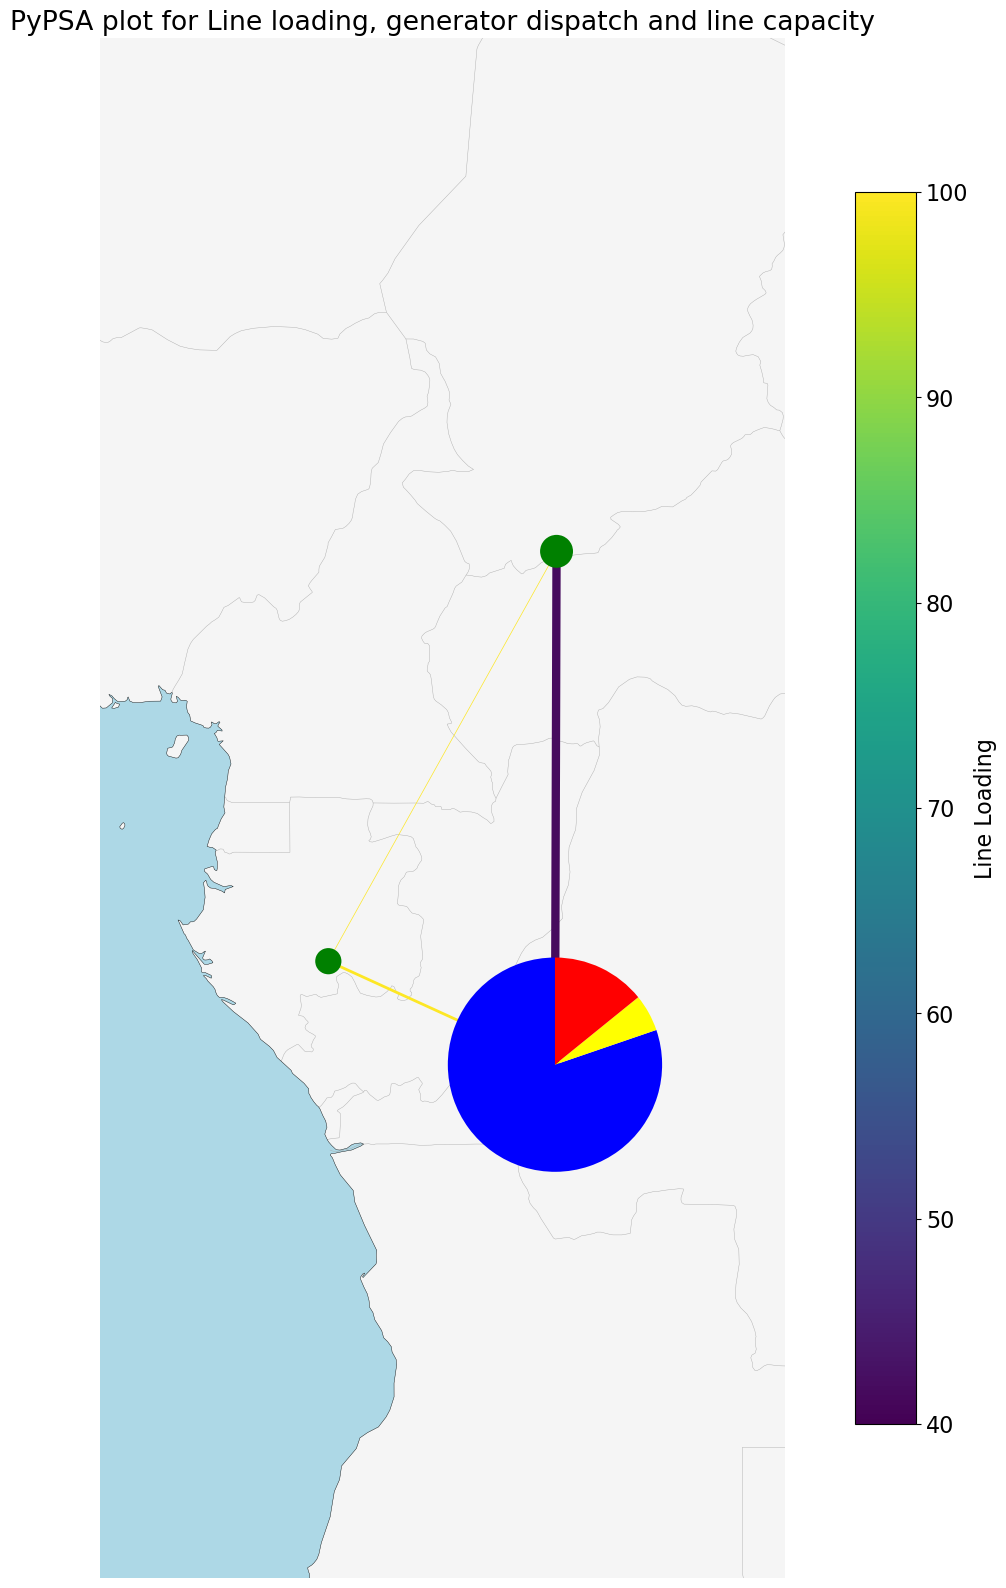

In [59]:
# Compute line loading
line_loading = n.lines_t.p0.iloc[0].abs() / n.lines.s_nom / n.lines.s_max_pu * 100
norm = plt.Normalize(vmin=40, vmax=100)

# Plot
fig = plt.figure(figsize=(18,20))
ax = plt.axes(projection=ccrs.PlateCarree())

n.plot(margin=1,
    ax=ax,
    bus_sizes=bus_sizes,
    bus_colors=bus_colors,
    line_widths=n.lines.s_nom / 100,
    line_colors=line_loading,
    line_norm=norm,
    color_geomap=True,
    title="PyPSA plot for Line loading, generator dispatch and line capacity"
    )

plt.colorbar(
    plt.cm.ScalarMappable(cmap="viridis", norm=norm),
    ax=ax,
    label="Line Loading",
    shrink=0.8)

#####  Reccommendation to Aloria to increase import capacity of hydro-electriciity from its neighbouring country

Increasing the import capacity will imply increasing the capacity of the transmission lines running from both Baray and Corsova. This would ensure that all capacity available can be imported safely without overloading the transmission lines. 